# Stanford CME 241 (Winter 2026) - Assignment 1

**Due: Friday, January 23 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):*

https://github.com/TommySini/RL-book/blob/master/assingments/Tommy%26Anthonyassignment1.ipynb

*Group members (replace below names with people in your group):*
- Tommaso Sini
- Anthony Viverito

## Imports

In [1]:
from collections import defaultdict
import itertools
import numpy as np
import matplotlib.pyplot as plt

from rl.distribution import Categorical, Constant
from rl.markov_process import FiniteMarkovProcess, MarkovProcess, NonTerminal, Terminal

## Question 1: Snakes and Ladders (Led by Anthony (a,b) and Tommy(c))

In the classic childhood game of Snakes and Ladders, all players start to the left of square 1 (call this position 0) and roll a 6-sided die to represent the number of squares they can move forward. The goal is to reach square 100 as quickly as possible. Landing on the bottom rung of a ladder allows for an automatic free-pass to climb, e.g. square 4 sends you directly to 14; whereas landing on a snake's head forces one to slide all the way to the tail, e.g. square 34 sends you to 6. Note, this game can be viewed as a Markov Process, where the outcome is only depedent on the current state and not the prior trajectory. In this question, we will ask you to both formally describe the Markov Process that describes this game, followed by coding up a version of the game to get familiar with the RL-book libraries.


### Problem Statement

How can we model this problem with a Markov Process?

---

### Subquestions

#### Part (A): MDP Modeling

Formalize the state space of the Snakes and Ladders game. Don't forget to specify the terminal state!

---

#### Part (B): Transition Probabilities

Write out the structure of the transition probabilities. Feel free to abbreviate all squares that do not have a snake or ladder.

---

#### Part (C): Modeling the Game

Code up a `transition_map: Transition[S]` data structure to represent the transition probabilities of the Snakes and Ladders Markov Process so you can model the game as an instance of `FiniteMarkovProcess`. Use the `traces` method to create sampling traces, and plot the graph of the distribution of time steps to finish the game. Use the image provided for the locations of the snakes and ladders.

https://drive.google.com/file/d/1yhP242sG092Ico_WOPKrUp8jVJHbuGHH/view?usp=sharing

---

### Part (A) Answer

A singular state would be the curent square you are occupying on the board. It is also important to note that you will start to the left of square 1 at '0'. Additionally, per the standard rules of snakes and ladders if you roll a move that overshoots 100 you stay put. When you do reach 100 the game ends meaning you have reached the terminal state. So formally the full state space is S = {0,1,2,...,100} with the terminal state being 100 and the non terminal states being {0,1,2,...,99}.

### Part (B) Answer


Let us begin with mapping the raw move from a non-terminal square $s \in \{0,\dots,99\}$, roll a fair die
$d \in \{1,2,3,4,5,6\}$ with $P(d=k)=\frac{1}{6}$ for $k=1,\dots,6$.


We can define the raw landing square using the "stay put" rule by the following:
$$
\mathrm{raw}(s,d)=
\begin{cases}
s+d, & \text{if } s+d \le 100,\\
s, & \text{if } s+d > 100.
\end{cases}
$$


As we approach the end many die outcomes map back to the same square meaning that the probabilities add up.


Now we must describe the Snakes/ladders rules. Once you have landed on a square x, you apply one of the two board’s forced moves:


- If x is a ladder bottom, jump up.
- If x is a snake head, slide down.



Ladders (bottom → top):

$$
1\to 38,\; 4\to 14,\; 8\to 10,\; 21\to 42,\; 28\to 76,\; 50\to 67,\; 71\to 92,\; 80\to 99.
$$


Snakes (head → tail):

$$
97\to 78,\; 95\to 56,\; 88\to 24,\; 62\to 18,\; 48\to 26,\; 36\to 6,\; 32\to 10.
$$


Therefore, the next square after rolling d from square s is:
$$
\mathrm{next}(s,d)=\mathrm{jump}(\mathrm{raw}(s,d)).
$$

Now we can express the full transition probability which represents the probability you go to s’ in one from starting from s.
$$
P(s\to s')=\sum_{d=1}^{6}\frac{1}{6}\,\mathbf{1}\{\mathrm{next}(s,d)=s'\}.
$$

### Part (C) Answer

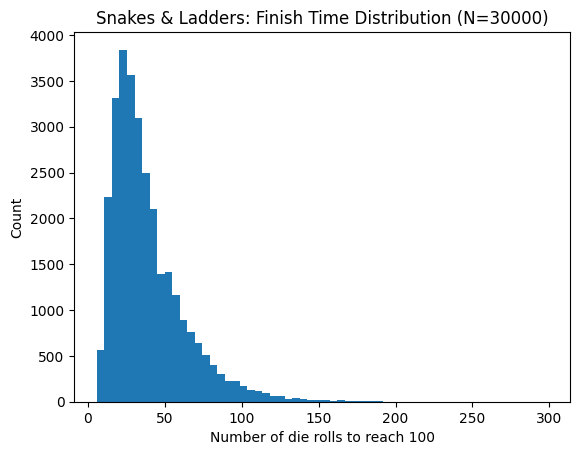

In [3]:


'''
Thought Process for Implementation the Code
1) Represent states as raw board positions & create functions representing board moves
2) Build transition map & implement into FiniteMarkovProcess class
3) Sample the traces and plot the graph of the distribtion of time steps to finish the game
'''

# Board Specifications

LADDER_SQUARES = {
    1: 38,
    4: 14,
    8: 10,
    21: 42,
    28: 76,
    50: 67,
    71: 92,
    80: 99
}

SNAKE_SQUARES = {
    97: 78,
    95: 56,
    88: 24,
    62: 18,
    48: 26,
    36: 6,
    32: 10
}

def next_state(square, die):
    # raw landing squares
    if square + die <= 100:
        landed = square + die
    else:
        landed = square

    # snake and ladder landing squarfes
    if landed in LADDER_SQUARES:
        return LADDER_SQUARES[landed]
    if landed in SNAKE_SQUARES:
        return SNAKE_SQUARES[landed]

    return landed

# create transition map and create instance of FiniteMarkovProcess
transition_map = {}

for square in range(0, 100):  # non-terminal squares only
    probs = defaultdict(float)

    for die in range(1, 7):
        next_square = next_state(square, die)
        probs[next_square] += 1.0 / 6.0

    transition_map[square] = Categorical(dict(probs))

markov_process = FiniteMarkovProcess(transition_map)

# Now begin tracing process
start_dist = Constant(NonTerminal(0)) # We always start at the same non-terminal square 0 (probability of 1)

# Create function to actual give an output for how many steps each trace iterates through to reach terminal state (100)
def steps_in_trace(trace) -> int:
    steps = 0
    for st in trace:
        if isinstance(st, Terminal):
            return steps
        steps += 1
    return steps

N = 30000
finish_times = []

for i in range(N):
    trace = next(markov_process.traces(start_dist)) # traces module runs infinitely, and so we only want one at a time and run a for loop for big distribution
    steps = steps_in_trace(trace)
    finish_times.append(steps)

# Now plot results with basic histogram using matploblib
plt.figure()
plt.hist(finish_times, bins=60)
plt.title(f"Snakes & Ladders: Finish Time Distribution (N={N})")
plt.xlabel("Number of die rolls to reach 100")
plt.ylabel("Count")
plt.show()

## Question 2: Markov Decision Processes (Led by Tommy)

Consider an MDP with an infinite set of states ${S} = \{1,2,3,\ldots \}$. The start state is $s=1$. Each state $s$ allows a continuous set of actions $a \in [0,1]$. The transition probabilities are given by:
$$\mathbb{P}[s+1 \mid s, a] = a, \mathbb{P}[s \mid s, a] = 1 - a \text{ for all } s \in S \text{ for all } a \in [0,1]$$
For all states $s \in {S}$ and actions $a \in [0,1]$, transitioning from $s$ to $s+1$ results in a reward of $1-a$ and transitioning from $s$ to $s$ results in a reward of $1+a$. The discount factor $\gamma=0.5$.

### Problem Statement

How can we derive a mathematical formulation for the value function and the optimal policy? And how do those functions change when we modify the action space?

---

### Subquestions

#### Part (A): Optimal Value Function  

Using the MDP Bellman Optimality Equation, calculate the Optimal Value Function $V^*(s)$ for all $s \in {S}$. Given $V^*(s)$, what is the optimal action, $a^*$, that maximizes the optimal value function?

---

#### Part (B): Optimal Policy  

Calculate an Optimal Deterministic Policy $\pi^*(s)$ for all $s \in {S}$.

---

#### Part (C): Changing the Action Space  

Let's assume that we modify the action space such that instead of $a \in [0,1]$ for all states, we restrict the action space to $a \in \left[0,\frac{1}{s}\right]$ for state $s$. This means that higher states have more restricted action spaces. How does this constraint affect:

- The form of the Bellman optimality equation?
- The optimal value function, $V^*(s)$?
- The structure of the optimal policy, $\pi^*(s)$?

---

### Part (A) Answer


The Bellman optimality equation for this MDP is

$$
V^*(s) = \max_{a \in [0,1]} \mathbb{E}\left[r(s,a,S') + \gamma V^*(S')\right].
$$

From state $s$, the transition dynamics and rewards are

$$
\begin{aligned}
\mathbb{P}(S' = s+1 \mid s,a) &= a, \quad r(s,a,s+1) = 1 - a, \\
\mathbb{P}(S' = s \mid s,a) &= 1 - a, \quad r(s,a,s) = 1 + a,
\end{aligned}
$$

with discount factor $\gamma = 0.5$.

Substituting into the Bellman equation,

$$
V^*(s) =
\max_{a \in [0,1]}
\left(
a\big[(1-a) + \gamma V^*(s+1)\big]
+ (1-a)\big[(1+a) + \gamma V^*(s)\big]
\right).
$$

Simplifying the immediate reward terms,

$$
a(1-a) + (1-a)(1+a) = 1 + a - 2a^2,
$$

so

$$
V^*(s) =
\max_{a \in [0,1]}
\left(1 + a - 2a^2
+ \gamma[aV^*(s+1) + (1-a)V^*(s)]
\right).
$$

Because the MDP is state-homogeneous, the optimal value function is constant:

$$
V^*(s) = V^*(s+1) = V^* \quad \forall s.
$$

Substituting and using $\gamma = 0.5$,

$$
V^* = 2 + 2a - 4a^2.
$$

Maximizing over $a \in [0,1]$,

$$
\frac{d}{da}(2 + 2a - 4a^2) = 2 - 8a = 0
\quad \Rightarrow \quad a^* = \tfrac14.
$$

Thus,

$$
V^*(s) = \tfrac94 \quad \forall s.
$$


### Part (B) Answer


From Part (A), the maximizing action is independent of the state. Therefore, the optimal deterministic policy is

$$
\pi^*(s) = \frac14 \quad \forall s \in \{1,2,3,\dots\}.
$$


### Part (C) Answer

Now suppose the action space depends on the state such that

$$
a \in \left[0,\frac{1}{s}\right].
$$

#### Bellman Optimality Equation Change:
The Bellman optimality equation becomes

$$
V^*(s) =
\max_{a \in [0,\,1/s]}
\Big(
a\big[(1-a) + \gamma V^*(s+1)\big]
+ (1-a)\big[(1+a) + \gamma V^*(s)\big]
\Big),
\qquad \gamma = 0.5.
$$

Equivalently, after simplifying the immediate reward terms,

$$
V^*(s) =
\max_{a \in [0,\,1/s]}
\Big(
1 + a - 2a^2
+ \gamma\big[aV^*(s+1) + (1-a)V^*(s)\big]
\Big).
$$

#### Optimal Value Function Change:
Because the action constraint depends on $s$, the optimal value function is no longer constant. For small states where the constraint is inactive,

$$
V^*(s) = \frac94 \quad \text{for } s = 1,2,3,4.
$$

For larger states, the constraint binds and the value function satisfies the recursion

$$
V^*(s) =
\frac{
1 + \frac1s - \frac{2}{s^2}
+ \gamma \cdot \frac1s V^*(s+1)
}{
1 - \gamma\left(1 - \frac1s\right)
},
\qquad s \ge 5,
$$

with $\gamma = 0.5$.

This shows that $V^*(s)$ decreases with $s$ as the feasible action set shrinks.

#### Optimal Policy Change:
The unconstrained optimal action from Part (A) is $a^* = \frac14$. With the state-dependent constraint, the optimal action is

$$
\pi^*(s) = a^*(s) = \min\!\left(\frac14, \frac1s\right).
$$

Equivalently,

$$
\pi^*(s) =
\begin{cases}
\frac14, & s \le 4, \\
\frac1s, & s \ge 5.
\end{cases}
$$

## Question 3: Frog in a Pond (Led by Anthony)

Consider an array of $n+1$ lilypads on a pond, numbered $0$ to $n$. A frog sits on a lilypad other than the lilypads numbered $0$ or $n$. When on lilypad $i$ ($1 \leq i \leq n-1$), the frog can croak one of two sounds: **A** or **B**.

- If it croaks **A** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to lilypad $i-1$ with probability $\frac{i}{n}$.
  - It is thrown to lilypad $i+1$ with probability $\frac{n-i}{n}$.
  
- If it croaks **B** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to one of the lilypads $0, \ldots, i-1, i+1, \ldots, n$ with uniform probability $\frac{1}{n}$.

A snake, perched on lilypad $0$, will eat the frog if it lands on lilypad $0$. The frog can escape the pond (and hence, escape the snake!) if it lands on lilypad $n$.

### Problem Statement

What should the frog croak when on each of the lilypads $1, 2, \ldots, n-1$, in order to maximize the probability of escaping the pond (i.e., reaching lilypad $n$ before reaching lilypad $0$)?

Although there are multiple ways to solve this problem, we aim to solve it by modeling it as a **Markov Decision Process (MDP)** and identifying the **Optimal Policy**.

---

### Subquestions

#### Part (A): MDP Modeling

Express the frog-escape problem as an MDP using clear mathematical notation by defining the following components:

- **State Space**: Define the possible states of the MDP.
- **Action Space**: Specify the actions available to the frog at each state.
- **Transition Function**: Describe the probabilities of transitioning between states for each action.
- **Reward Function**: Specify the reward associated with the states and transitions.

---

#### Part (B): Python Implementation

There is starter code below to solve this problem programatically. Fill in each of the $6$ `TODO` areas in the code. As a reference for the transition probabilities and rewards, you can make use of the example in slide 16/31 from the following slide deck: https://github.com/coverdrive/technical-documents/blob/master/finance/cme241/Tour-MP.pdf.

Write Python code that:

- Models this MDP.
- Solves the **Optimal Value Function** and the **Optimal Policy**.

Feel free to use/adapt code from the textbook. Note, there are other libraries that are needed to actually run this code, so running it will not do anything. Just fill in the code so that it could run assuming that the other libraries are present.

---

#### Part (C): Visualization and Analysis

What patterns do you observe for the **Optimal Policy** as you vary $n$ from $3$ to $25$? When the frog is on lilypad $13$ (with $25$ total), what action should the frog take? Is this action different than the action the frog should take if it is on lilypad $1$?

---

### Part (A) Answer

#### State Space:  

The frog's position on a lilypad is the state:

$$
\mathcal{S}=\{0,1,\ldots,n\}.
$$

$\mathcal{S} = n$ and $\mathcal{S} = 0$ are defined as terminal states because teh frog will cease to be active on the pond. Landing on lilypad $\mathbf{0}$ means the frog is eaten. Landing on lilypad $\mathbf{n}$ means the frog has escaped.

#### Action Space:  

For each non-terminal state $i \in \{1,\ldots,n-1\}$
, the frog has two options: croak \(A\) or croak \(B\).

$$
\mathcal{A}(i)=\{A,B\}.
$$

At the terminal states, the action is irrelevant; we may define

$$
\mathcal{A}(0)=\mathcal{A}(n)=\varnothing.
$$

#### Transition Function:  

Denote $$\mathcal{P}(s' | s,a)$$
If a = A at state $i \in {1,...,n-1}$:
$$
\mathcal{P}(i - 1|i,A) = \frac{i}{n}, \mathcal{ P}(i + 1|i,A) = \frac{n-i}{n}
$$
If a = B at state $i \in {1,...,n-1}$:
$$
P(j \mid i, B)=\frac{1}{n}
\quad \text{for every } j \in \{0,1,\ldots,n\}\setminus\{i\}.
$$

#### Reward Function:  

Let the reward be
$$
R(s,a,s') =
\begin{cases}
1 & \text{if } s' = n,\\
0 & \text{otherwise.}
\end{cases}
$$

Define the value function as the expected total reward:
$$
V^\pi(s) = \mathbb{E}_\pi\!\left[\sum_{t=0}^{T-1} R(S_t, A_t, S_{t+1}) \,\middle|\, S_0=s\right],
$$
where $T$ is the (random) time when the process first hits state $0$ or $n$.

Then
$$
V^\pi(s) = \Pr_\pi(\text{hit } n \text{ before } 0 \mid S_0=s).
$$

Therefore the optimal value function satisfies:
$$
V^*(0)=0,\qquad V^*(n)=1,
$$
and for $1 \le i \le n-1$,
$$
V^*(i)=\max_{a\in\{A,B\}} \sum_{j\in\mathcal{S}} P(j \mid i,a)\,V^*(j).
$$
</span>

### Part (B) Answer

In [5]:
MDPRefined = dict
def get_lily_pads_mdp(n: int) -> MDPRefined:
    data = {
        i: {
            'A': {
                i - 1: i / n,
                i + 1: (n - i) / n,
            },
            'B': {
                j: 1 / n,
            }
        } for i in range(1, n)
    }
    data[0] = {'A': {0: 1.0}, 'B': {0: 1.0}}
    data[n] = {'A': {n: 1.0}, 'B': {n: 1.0}}

    gamma = 1.0
    return MDPRefined(data, gamma)



Mapping = dict
def direct_bellman(n: int) -> Mapping[int, float]:
    vf = [0.5] * (n + 1)
    vf[0] = 0.
    vf[n] = 0.
    tol = 1e-8
    epsilon = tol * 1e4
    while epsilon >= tol:
        old_vf = [v for v in vf]
        for i in range(1, n):
            vf[i] = max(
                (i / n) * old_vf[i - 1] + ((n - i) / n) * old_vf[i + 1],
                (1 / n) * sum(old_vf[j] for j in range(n + 1) if j != i)
            )
        epsilon = max(abs(old_vf[i] - v) for i, v in enumerate(vf))
    return {v: f for v, f in enumerate(vf)}

### Part (C) Answer

The optimal policy is  to croak B only on lilypad 1 and to croak A on lilypads 2 through n−1. An Edge case is that for n=2, lilypad 1 is A. For n = 25 On lilypad 13 croak A and on lilypad 1 croak B. 

## Question 4: Manual Value Iteration (Led by Tommy)

Consider a simple MDP with ${S} = \{s_1, s_2, s_3\}, {T} = \{s_3\}, {A} = \{a_1, a_2\}$. The State Transition Probability function  
$${P}: {N} \times {A} \times {S} \rightarrow [0, 1]$$  
is defined as:  
$${P}(s_1, a_1, s_1) = 0.25, {P}(s_1, a_1, s_2) = 0.65, {P}(s_1, a_1, s_3) = 0.1$$  
$${P}(s_1, a_2, s_1) = 0.1, {P}(s_1, a_2, s_2) = 0.4, {P}(s_1, a_2, s_3) = 0.5$$  
$${P}(s_2, a_1, s_1) = 0.3, {P}(s_2, a_1, s_2) = 0.15, {P}(s_2, a_1, s_3) = 0.55$$  
$${P}(s_2, a_2, s_1) = 0.25, {P}(s_2, a_2, s_2) = 0.55, {P}(s_2, a_2, s_3) = 0.2$$  

The Reward Function  
$${R}: {N} \times {A} \rightarrow \mathbb{R}$$  
is defined as:  
$${R}(s_1, a_1) = 8.0, {R}(s_1, a_2) = 10.0$$  
$${R}(s_2, a_1) = 1.0, {R}(s_2, a_2) = -1.0$$  

Assume a discount factor of $\gamma = 1$.

### Problem Statement

Your task is to determine an Optimal Deterministic Policy **by manually working out** (not with code) the first two iterations of the Value Iteration algorithm.

---

### Subquestions

#### Part (A): 2 Iterations

1. Initialize the Value Function for each state to be its $\max$ (over actions) reward, i.e., we initialize the Value Function to be $v_0(s_1) = 10.0, v_0(s_2) = 1.0, v_0(s_3) = 0.0$. Then manually calculate $q_k(\cdot, \cdot)$ and $v_k(\cdot)$ from $v_{k - 1}(\cdot)$ using the Value Iteration update, and then calculate the greedy policy $\pi_k(\cdot)$ from $q_k(\cdot, \cdot)$ for $k = 1$ and $k = 2$ (hence, 2 iterations).

---

#### Part (B): Argument

1. Now argue that $\pi_k(\cdot)$ for $k > 2$ will be the same as $\pi_2(\cdot)$. *Hint*: You can make the argument by examining the structure of how you get $q_k(\cdot, \cdot)$ from $v_{k-1}(\cdot)$. With this argument, there is no need to go beyond the two iterations you performed above, and so you can establish $\pi_2(\cdot)$ as an Optimal Deterministic Policy for this MDP.

---

#### Part (C): Policy Evaluation

1. Using the policy $\pi_2(\cdot)$, compute the exact value function $V^{\pi_2}(s)$ for all $s\in S$.

---

#### Part (D): Sensitivity Analysis

Assume the reward for $R(s_1, a_2)$ is modified to $11.0$ instead of $10.0$.

1. Perform one iteration of Value Iteration starting from the initialized value function $v_0(s)$, where $v_0(s)$ remains the same as in the original problem.
2. Determine whether this change impacts the Optimal Deterministic Policy $\pi(\cdot)$. If it does, explain why.

---

### Part (A) Answer
We must compute $q_k$:
$$
q_1(s_1,a_1), q_1(s_1,a_2), q_1(s_2,a_1), q_1(s_2,a_2)
$$
Using the formula
$$
q_k(s,a) = R(s,a)+γ\sum_{s_1}^{s_3}P(s,a,s)v_{k-1}(s)
$$
We get

$$
q_1(s_1,a_1)=8 + (0.25\cdot10 + 0.65\cdot1 + 0.1\cdot0)=11.15
$$

$$
q_1(s_1,a_2)=10 + (0.1\cdot10 + 0.4\cdot1 + 0.5\cdot0)=11.4
$$

$$
q_1(s_2,a_1)=1 + (0.3\cdot10 + 0.15\cdot1 + 0.55\cdot0)=4.15
$$

$$
q_1(s_2,a_2)=-1 + (0.25\cdot10 + 0.55\cdot1 + 0.2\cdot0)=2.05
$$

Lets now compute $v_1$ using the formula

$$
v_k(s)=\max_a q_k(s,a)
$$
$$
v_1(s_1)=\max(11.15,11.4)=11.4
$$

$$
v_1(s_2)=\max(4.15,2.05)=4.15
$$

$$
v_1(s_3)=0
$$

Lets now get greedy policy $\pi_1$ using the formula
$$
\pi_k(s)=\arg\max_a q_k(s,a)
$$
$$
\pi_1(s_1)=a_2,\quad \pi_1(s_2)=a_1
$$

Now k=2:
Compute $q_2$
$$
q_2(s_1,a_1)=8 + (0.25\cdot11.4 + 0.65\cdot4.15 + 0.1\cdot0)=13.5475
$$

$$
q_2(s_1,a_2)=10 + (0.1\cdot11.4 + 0.4\cdot4.15 + 0.5\cdot0)=12.8
$$

$$
q_2(s_2,a_1)=1 + (0.3\cdot11.4 + 0.15\cdot4.15 + 0.55\cdot0)=5.0425
$$

$$
q_2(s_2,a_2)=-1 + (0.25\cdot11.4 + 0.55\cdot4.15 + 0.2\cdot0)=4.1325
$$

Now compute $v_2$
$$
v_2(s_1)=\max(13.5475,12.8)=13.5475
$$

$$
v_2(s_2)=\max(5.0425,4.1325)=5.0425
$$

$$
v_2(s_3)=0
$$

Lets now get our second k=2 greedy policy:
$$
\pi_2(s_1)=a_1,\quad \pi_2(s_2)=a_1
$$


### Part (B) Answer:  

We want to show that for all $k>2$:

$$
\pi_k(s_1)=\pi_2(s_1)
$$

Recall

$$
q_k(s,a)=R(s,a)+\gamma\sum_{s'}P(s,a,s')v_{k-1}(s')
$$

and

$$
\pi_k(s)=\arg\max_a q_k(s,a).
$$

From Part (A), at $k=2$ we found:

$$
q_2(s_1,a_1)=13.5475,\quad q_2(s_1,a_2)=12.8
$$

so

$$
q_2(s_1,a_1)>q_2(s_1,a_2)
\quad\Rightarrow\quad
\pi_2(s_1)=a_1.
$$

Since $q_k(s_1,a)$ is obtained from $v_{k-1}$ using fixed rewards and fixed transition probabilities, the ordering between $q_k(s_1,a_1)$ and $q_k(s_1,a_2)$ does not change after it has separated in favor of $a_1$.

Therefore,

$$
\pi_k(s_1)=a_1=\pi_2(s_1)\quad \text{for all } k>2.
$$

### Part (C) Answer:  

Using $\pi_2$, we have:
$$
\pi_2(s_1)=a_1,\quad \pi_2(s_2)=a_1,\quad V_{\pi_2}(s_3)=0
$$
(with $s_3$ terminal and $\gamma=1$).

Bellman equations:
$$
V_{\pi_2}(s)=R(s,\pi_2(s))+\sum_{s'}P(s,\pi_2(s),s')V_{\pi_2}(s')
$$

So for $s_1$ (using $a_1$):
$$
V_{\pi_2}(s_1)=8 + 0.25V_{\pi_2}(s_1)+0.65V_{\pi_2}(s_2)+0.1V_{\pi_2}(s_3)
$$
$$
V_{\pi_2}(s_1)=8 + 0.25V_{\pi_2}(s_1)+0.65V_{\pi_2}(s_2)
$$

For $s_2$ (using $a_1$):
$$
V_{\pi_2}(s_2)=1 + 0.3V_{\pi_2}(s_1)+0.15V_{\pi_2}(s_2)+0.55V_{\pi_2}(s_3)
$$
$$
V_{\pi_2}(s_2)=1 + 0.3V_{\pi_2}(s_1)+0.15V_{\pi_2}(s_2)
$$

Solve the system:
$$
0.75V_{\pi_2}(s_1)-0.65V_{\pi_2}(s_2)=8
$$
$$
-0.3V_{\pi_2}(s_1)+0.85V_{\pi_2}(s_2)=1
$$

We get:
$$
V_{\pi_2}(s_1)=\frac{2980}{177}\approx 16.8362
$$
$$
V_{\pi_2}(s_2)=\frac{420}{59}\approx 7.1186
$$
$$
V_{\pi_2}(s_3)=0
$$

### Part (D) Answer

#### Value Iteration:  

We change only the reward:
$$
R(s_1,a_2)=11 \text{ instead of } 10
$$
and keep the same initialization:
$$
v_0(s_1)=10,\quad v_0(s_2)=1,\quad v_0(s_3)=0,\quad \gamma=1.
$$

Using
$$
q_1(s,a)=R(s,a)+\sum_{s'}P(s,a,s')v_0(s')
$$

Compute $q_1$:

$$
q_1(s_1,a_1)=8 + (0.25\cdot10 + 0.65\cdot1 + 0.1\cdot0)=11.15
$$

$$
q_1(s_1,a_2)=11 + (0.1\cdot10 + 0.4\cdot1 + 0.5\cdot0)=12.4
$$

$$
q_1(s_2,a_1)=1 + (0.3\cdot10 + 0.15\cdot1 + 0.55\cdot0)=4.15
$$

$$
q_1(s_2,a_2)=-1 + (0.25\cdot10 + 0.55\cdot1 + 0.2\cdot0)=2.05
$$

Now compute $v_1$:

$$
v_1(s_1)=\max(11.15,12.4)=12.4
$$

$$
v_1(s_2)=\max(4.15,2.05)=4.15
$$

$$
v_1(s_3)=0
$$

Greedy policy after one iteration:

$$
\pi_1(s_1)=a_2,\quad \pi_1(s_2)=a_1
$$

#### Optimal Deterministic Policy:  

ignore

## Question 5: Fixed-Point and Policy Evaluation True/False Questions (Led by Tommy)

### Recall Section: Key Formulas and Definitions

#### Bellman Optimality Equation
The Bellman Optimality Equation for state-value functions is:
$$
V^*(s) = \max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^*(s') \right].
$$
For action-value functions:
$$
Q^*(s, a) = R(s, a) + \gamma \sum_{s'} P(s, a, s') \max_{a'} Q^*(s', a').
$$

#### Contraction Property
The Bellman Policy Operator $B^\pi$ is a contraction under the $L^\infty$-norm:
$$
\|B^\pi(X) - B^\pi(Y)\|_\infty \leq \gamma \|X - Y\|_\infty.
$$
This guarantees convergence to a unique fixed point.

#### Policy Iteration
Policy Iteration alternates between:
1. **Policy Evaluation**: Compute $V^\pi$ for the current policy $\pi$.
2. **Policy Improvement**: Generate a new policy $\pi'$ by setting:
   $$
   \pi'(s) = \arg\max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^\pi(s') \right].
   $$

#### Discounted Return
The discounted return from time step $t$ is:
$$
G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i,
$$
where $\gamma \in [0, 1)$ is the discount factor.

### True/False Questions (Provide Justification)

1. **True/False**: If $Q^\pi(s, a) = 5$, $P(s, a, s') = 0.5$ for $s' \in \{s_1, s_2\}$, and the immediate reward $R(s, a)$ increases by $2$, the updated action-value function $Q^\pi(s, a)$ also increases by $2$.


---

2. **True/False**: For a discount factor $\gamma = 0.9$, the discounted return for rewards $R_1 = 5, R_2 = 3, R_3 = 1$ is greater than $6$.

---

3. **True/False**: The Bellman Policy Operator $B^\pi(V) = R^\pi + \gamma P^\pi \cdot V$ satisfies the contraction property for all $\gamma \in [0, 1)$, ensuring a unique fixed point.

---

4. **True/False**: In Policy Iteration, the Policy Improvement step guarantees that the updated policy $\pi'$ will always perform strictly better than the previous policy $\pi$.

---

5. **True/False**: If $Q^\pi(s, a) = 10$ for all actions $a$ in a state $s$, then the corresponding state-value function $V^\pi(s) = 10$, regardless of the policy $\pi$.

---

6. **True/False**: The discounted return $G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i$ converges to a finite value for any sequence of bounded rewards if $\gamma < 1$.

---

### Answers (Provide justification, brief explanations are fine)

### Question 1
The action-value function is formally defined as
$$
Q_\pi(s,a)=R(s,a)+\gamma\sum_{s'}P(s,a,s')V_\pi(s').
$$
While the immediate reward $R(s,a)$ increases by $2$, the transition probabilities $P(s,a,s')$ and the value function $V_\pi(s')$ remain unchanged, therefore we can rewrite our action-value function as
$$
Q_\pi^{\text{new}}(s,a)=(R(s,a)+2)+\gamma\sum_{s'}P(s,a,s')V_\pi(s')
=Q_\pi^{\text{old}}(s,a)+2.
$$
Therefore, the updated action-value function $Q_\pi(s,a)$ also increases by $2$.

So True

---

### Question 2
Formally, the discounted return can be denoted mathematically as
$$
G_t=\sum_{i=t+1}^{\infty}\gamma^{\,i-t-1}R_i,
$$
where $\gamma=0.9$. Therefore plugging in our values we get
$$
G=5+(0.9)(3)+(0.9)^2(1)=8.51>6.
$$
Hence, we get a discounted return that is greater than six, so True.

---

### Question 3
If $\gamma<1$, then repeatedly applying the Bellman policy operator $B_\pi$ causes the value function to converge to the same value function $V_\pi$, regardless of the initial value function $V_0$:
$$
V_{k+1}=B_\pi(V_k),
\quad \text{where} \quad
V_k\to V_\pi \text{ for any } V_0.
$$
This holds because $B_\pi$ is a contraction mapping. For any value functions $V$ and $W$,
$$
\|B_\pi(V)-B_\pi(W)\|_\infty
=\|\gamma P_\pi (V-W)\|_\infty
\le \gamma\|V-W\|_\infty,
$$
and since $\gamma<1$, repeated application of $B_\pi$ shrinks the distance between successive iterates. By the Banach Fixed-Point Theorem, $B_\pi$ has a unique fixed point $V_\pi$ satisfying
$$
V_\pi=B_\pi(V_\pi),
$$
and the sequence $\{V_k\}$ converges to $V_\pi$ for any initial value function $V_0$.

So True

---

### Question 4
The Policy Improvement step guarantees that the updated policy $\pi'$ is no worse than the previous policy $\pi$, but not necessarily strictly better. Specifically,
$$
V_{\pi'}(s)\ge V_\pi(s)\quad \text{for all states } s.
$$
Strict improvement is not guaranteed when the current policy $\pi$ is already optimal or when multiple actions yield the same value, in which case
$$
V_{\pi'}(s)=V_\pi(s)\quad \text{for all } s.
$$

So False

---

### Question 5
By definition, the state-value function evaluates a state under a policy, while the action-value function evaluates individual actions within a state. The relationship between them is
$$
V_\pi(s)=\sum_a \pi(a\mid s)\,Q_\pi(s,a).
$$
If $Q_\pi(s,a)=10$ for all actions $a$ in state $s$, then the policy-weighted average is independent of which action is chosen:
$$
V_\pi(s)=\sum_a \pi(a\mid s)\,10
=10\sum_a \pi(a\mid s)=10.
$$
Therefore, when all action-values are equal, the state-value function equals that common value regardless of the policy $\pi$.

So True

---

### Question 6
Since $0\le \gamma<1$, the discount factor $\gamma^k$ will reach zero as $k$ grows to infinity, denoted by
$$
\gamma^k\to 0 \quad \text{as } k\to\infty.
$$
This means that rewards further in the future are weighted by terms that are asymptotically reaching zero. Therefore the discounted return
$$
G_t=\sum_{i=t+1}^{\infty}\gamma^{\,i-t-1}R_i
$$
converges.

Lets show this mathematically. Assume rewards are bounded: $|R_i|\le R_{\max}$. Consider the tail after $N$ terms:
$$
\left|
\sum_{i=t+N+1}^{\infty}\gamma^{\,i-t-1}R_i
\right|
\le
\sum_{i=t+N+1}^{\infty}\gamma^{\,i-t-1}|R_i|
\le
R_{\max}\sum_{i=t+N+1}^{\infty}\gamma^{\,i-t-1}.
$$
Since $0\le \gamma<1$, the weights $\gamma^{\,i-t-1}$ shrink to $0$ fast, so this tail can be made arbitrarily small by choosing $N$ large enough. Therefore the discounted return converges to a finite value.

So True
